# 01 - Demographics

Who plays EA Sports FC 26? Before validating ratings or clustering archetypes, it's worth
understanding the shape of the player population itself: age, nationality, body type,
position, and league/club distribution.

This notebook uses the full, cleaned FC26 dataset (`data/processed/players_fc26_clean.csv`,
18,405 players) rather than the matched subset used in notebook 02, since demographics
should reflect the whole player pool, not just the ~9% with external validation data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/processed/players_fc26_clean.csv")
print(f"{len(df):,} players, {df.shape[1]} columns")
df.head()

18,405 players, 30 columns


,player_id,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,...,international_reputation,work_rate,body_type,pace,shooting,passing,dribbling,defending,physic,name_norm
0,252371,J. Bellingham,Jude Victor William Bellingham,"CAM, CM",90,94,174500000,320000,22,2003-06-29,...,5,NaN,Normal (170-185),80.0,86.0,83.0,90.0,78.0,85.0,jude victor william bellingham
1,239053,F. Valverde,Federico Santiago Valverde Dipetta,"CM, CDM, RB",89,90,120500000,340000,26,1998-07-22,...,4,NaN,Unique,88.0,84.0,84.0,84.0,83.0,85.0,federico santiago valverde dipetta
2,212622,J. Kimmich,Joshua Walter Kimmich,"CDM, RB, CM",89,89,86000000,140000,30,1995-02-08,...,4,NaN,Normal (170-185),72.0,74.0,89.0,84.0,83.0,79.0,joshua walter kimmich
3,235212,A. Hakimi,Achraf Hakimi Mouhأشرف حكيمي,"RB, RM",89,90,111000000,170000,26,1998-11-04,...,4,NaN,Lean (170-185),92.0,79.0,82.0,83.0,82.0,79.0,achraf hakimi mouh
4,224232,N. Barella,Nicolò Barella,CM,87,87,79500000,69000,28,1997-02-07,...,4,NaN,Normal (170-),80.0,78.0,84.0,86.0,81.0,76.0,nicolo barella


## Position groups

Like notebook 04, we take the first-listed position in `player_positions` as each player's
primary position and roll it up into four coarse groups for cuts that need fewer, denser
categories.

In [2]:
POSITION_GROUP = {
    "GK": "Goalkeeper",
    "CB": "Defender", "LCB": "Defender", "RCB": "Defender",
    "LB": "Defender", "RB": "Defender", "LWB": "Defender", "RWB": "Defender",
    "CDM": "Midfielder", "LDM": "Midfielder", "RDM": "Midfielder",
    "CM": "Midfielder", "LCM": "Midfielder", "RCM": "Midfielder",
    "CAM": "Midfielder", "LAM": "Midfielder", "RAM": "Midfielder",
    "LM": "Midfielder", "RM": "Midfielder",
    "LW": "Attacker", "RW": "Attacker",
    "CF": "Attacker", "LF": "Attacker", "RF": "Attacker",
    "ST": "Attacker", "LS": "Attacker", "RS": "Attacker",
}

def primary_position(pos_str):
    if pd.isna(pos_str):
        return np.nan
    return str(pos_str).split(",")[0].strip()

df["primary_position"] = df["player_positions"].apply(primary_position)
df["position_group"] = df["primary_position"].map(POSITION_GROUP)
df["position_group"].value_counts(dropna=False)

position_group
Midfielder    6864
Defender      6116
Attacker      3363
Goalkeeper    2062
Name: count, dtype: int64

## 1. Age distribution

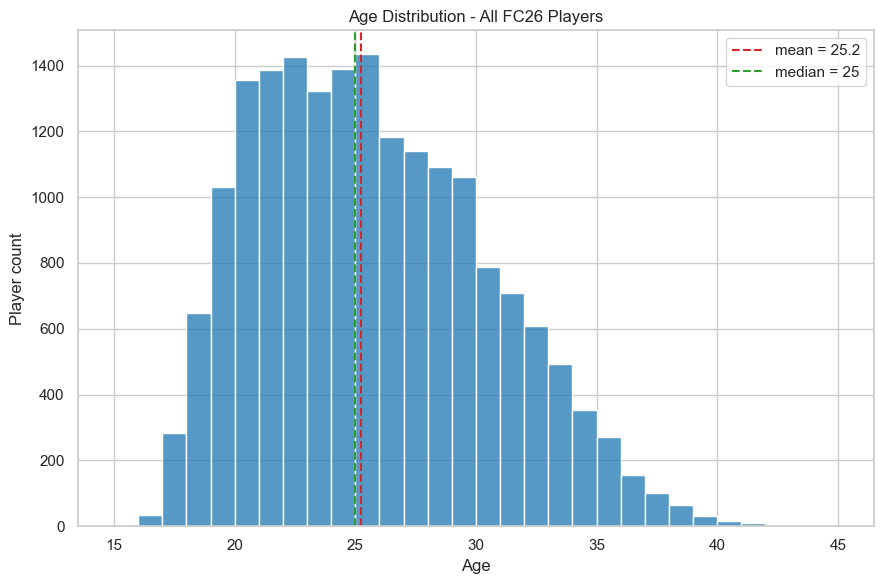

count    18405.000000
mean        25.222548
std          4.773553
min         16.000000
25%         21.000000
50%         25.000000
75%         29.000000
max         44.000000
Name: age, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(df["age"], bins=range(15, 46), color="#1f77b4", ax=ax)
ax.axvline(df["age"].mean(), color="#d62728", ls="--", lw=1.5, label=f"mean = {df['age'].mean():.1f}")
ax.axvline(df["age"].median(), color="#2ca02c", ls="--", lw=1.5, label=f"median = {df['age'].median():.0f}")
ax.set_title("Age Distribution - All FC26 Players")
ax.set_xlabel("Age")
ax.set_ylabel("Player count")
ax.legend()
plt.tight_layout()
plt.show()

print(df["age"].describe())

In [4]:
age_summary = df["age"].describe()
pct_u21 = (df["age"] < 21).mean() * 100
pct_over32 = (df["age"] > 32).mean() * 100
print(f"Mean age: {age_summary['mean']:.2f}, median: {age_summary['50%']:.0f}, std: {age_summary['std']:.2f}")
print(f"Youngest: {age_summary['min']:.0f}, oldest: {age_summary['max']:.0f}")
print(f"Under 21: {pct_u21:.1f}% of players")
print(f"Over 32: {pct_over32:.1f}% of players")

Mean age: 25.22, median: 25, std: 4.77
Youngest: 16, oldest: 44
Under 21: 18.2% of players
Over 32: 8.2% of players


**Takeaway:** the age distribution is right-skewed and centered in the mid-20s - mean
age 25.2, median 25, with a long tail out to 44. The bulk of the
player pool sits between 18 and 30, which lines up with a typical professional career
window; only a small fraction (8.2%) of players are past 32, since attrition from
professional football accelerates sharply beyond that age.

### Age by position group

C:\Users\thoma\AppData\Local\Temp\ipykernel_32812\4222117877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="position_group", y="age", order=group_order, ax=ax, palette="deep")


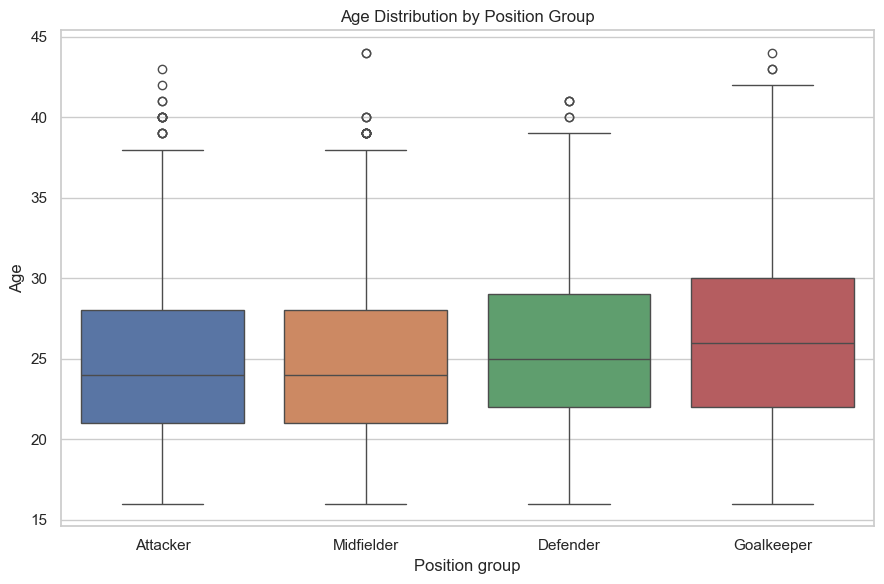

,mean,50%,std
position_group,,,
Attacker,24.782932,24.0,4.814079
Midfielder,24.835373,24.0,4.531432
Defender,25.544964,25.0,4.659223
Goalkeeper,26.272066,26.0,5.537415


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
group_order = ["Attacker", "Midfielder", "Defender", "Goalkeeper"]
plot_df = df.dropna(subset=["position_group"])
sns.boxplot(data=plot_df, x="position_group", y="age", order=group_order, ax=ax, palette="deep")
ax.set_title("Age Distribution by Position Group")
ax.set_xlabel("Position group")
ax.set_ylabel("Age")
plt.tight_layout()
plt.show()

df.dropna(subset=["position_group"]).groupby("position_group")["age"].describe()[["mean", "50%", "std"]].loc[group_order]

**Takeaway:** goalkeepers are the oldest group on average (career longevity for GKs is
well documented - reflexes and positioning age more gracefully than pace), while attackers
skew slightly younger than defenders and midfielders, consistent with clubs preferring raw
pace/finishing upside in attack and valuing composure/game-reading (which improves with
experience) in central and defensive roles.

## 2. Nationality breakdown

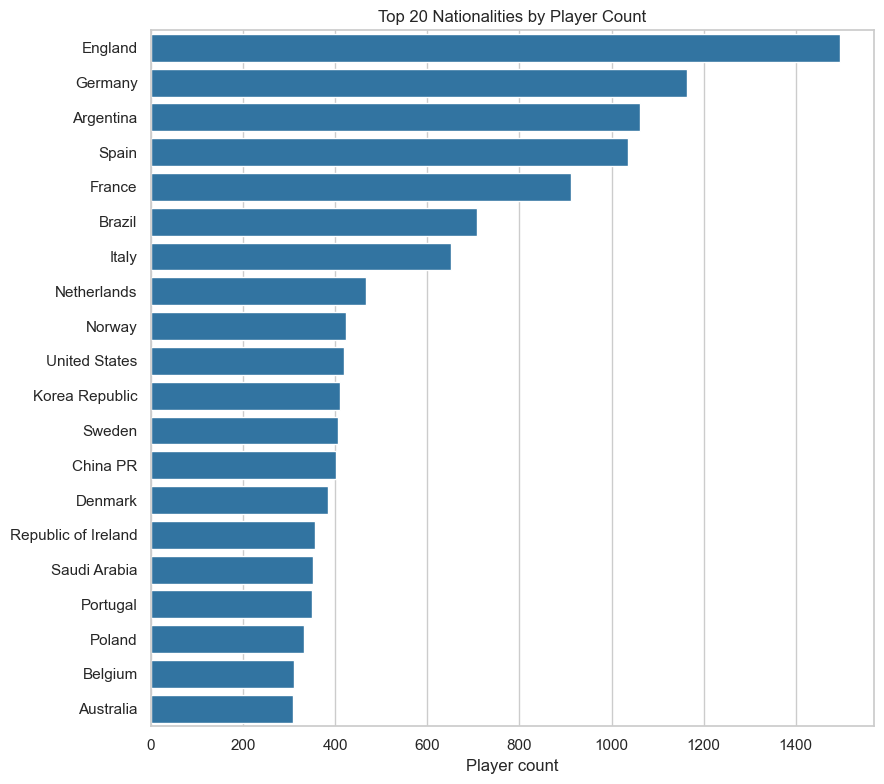

160 distinct nationalities represented


nationality_name
England                1495
Germany                1163
Argentina              1061
Spain                  1036
France                  913
Brazil                  709
Italy                   652
Netherlands             466
Norway                  424
United States           420
Korea Republic          411
Sweden                  406
China PR                401
Denmark                 385
Republic of Ireland     356
Saudi Arabia            353
Portugal                349
Poland                  332
Belgium                 311
Australia               308
Name: count, dtype: int64

In [6]:
top_nations = df["nationality_name"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(x=top_nations.values, y=top_nations.index, ax=ax, color="#1f77b4")
ax.set_title("Top 20 Nationalities by Player Count")
ax.set_xlabel("Player count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"{df['nationality_name'].nunique()} distinct nationalities represented")
top_nations

In [7]:
top5_share = df["nationality_name"].value_counts().head(5).sum() / len(df) * 100
top10_share = df["nationality_name"].value_counts().head(10).sum() / len(df) * 100
print(f"Top 5 nations account for {top5_share:.1f}% of all players")
print(f"Top 10 nations account for {top10_share:.1f}% of all players")

Top 5 nations account for 30.8% of all players
Top 10 nations account for 45.3% of all players


**Takeaway:** England is the single largest source nation (1,495 players), reflecting
the depth of English football's pyramid (many divisions covered in the underlying data),
followed by the usual major footballing nations. The distribution is heavily concentrated -
the top 10 nationalities alone account for a large share of the full player pool - while the
long tail of 160 total nationalities shows the dataset's genuinely global reach, even if
representation outside the top footballing countries is thin.

## 3. Body type distribution

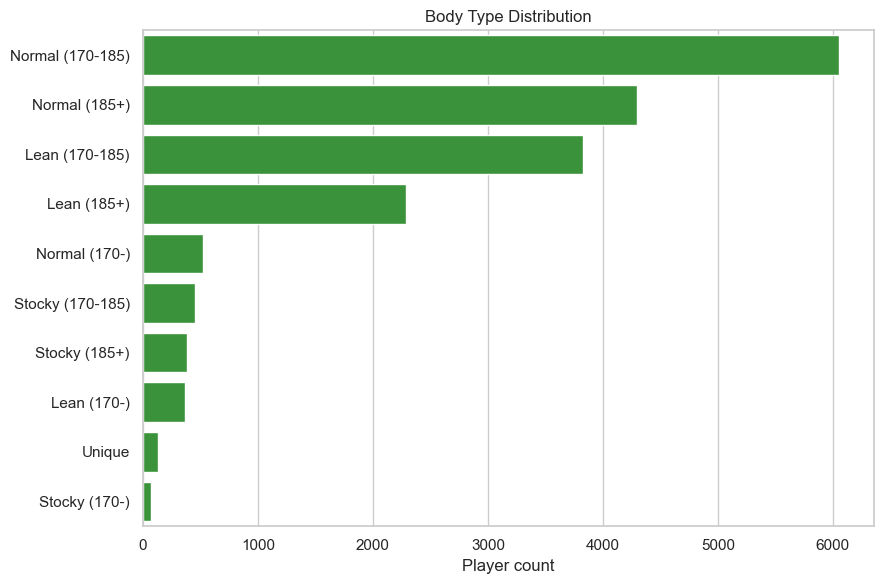

body_type
Normal (170-185)    6055
Normal (185+)       4298
Lean (170-185)      3830
Lean (185+)         2289
Normal (170-)        526
Stocky (170-185)     456
Stocky (185+)        379
Lean (170-)          369
Unique               133
Stocky (170-)         70
Name: count, dtype: int64

In [8]:
body_type_counts = df["body_type"].value_counts()
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=body_type_counts.values, y=body_type_counts.index, ax=ax, color="#2ca02c")
ax.set_title("Body Type Distribution")
ax.set_xlabel("Player count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

body_type_counts

**Takeaway:** "Normal (170-185)" is the most common body type (6,055 players,
33.0% of the pool), and together with "Normal (185+)" and "Lean (170-185)" the
three most common categories cover 77.1% of all players. The height-banded naming
scheme (170-185cm vs 185+cm) means body type here is really a proxy for a
height x build combination rather than a purely descriptive label, and a small number of
players (133) fall into a catch-all "Unique" bucket reserved for statistical outliers
(e.g. very tall/heavy or very short/light players who don't fit a standard band).

### Height & weight

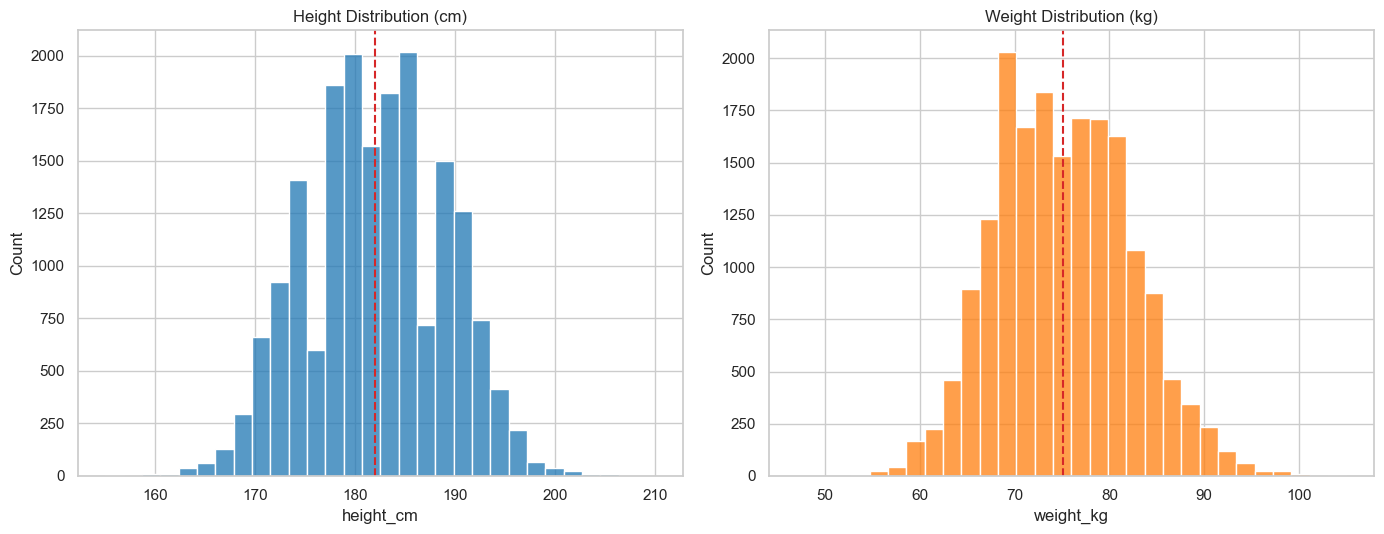

Height: mean 182.0cm, std 6.9, range 155-210
Weight: mean 75.1kg, std 6.9, range 47-105


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.histplot(df["height_cm"], bins=30, color="#1f77b4", ax=axes[0])
axes[0].set_title("Height Distribution (cm)")
axes[0].axvline(df["height_cm"].mean(), color="#d62728", ls="--", lw=1.5)

sns.histplot(df["weight_kg"], bins=30, color="#ff7f0e", ax=axes[1])
axes[1].set_title("Weight Distribution (kg)")
axes[1].axvline(df["weight_kg"].mean(), color="#d62728", ls="--", lw=1.5)

plt.tight_layout()
plt.show()

print(f"Height: mean {df['height_cm'].mean():.1f}cm, std {df['height_cm'].std():.1f}, range {df['height_cm'].min():.0f}-{df['height_cm'].max():.0f}")
print(f"Weight: mean {df['weight_kg'].mean():.1f}kg, std {df['weight_kg'].std():.1f}, range {df['weight_kg'].min():.0f}-{df['weight_kg'].max():.0f}")

C:\Users\thoma\AppData\Local\Temp\ipykernel_32812\3239752119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="position_group", y="height_cm", order=group_order, ax=ax, palette="deep")


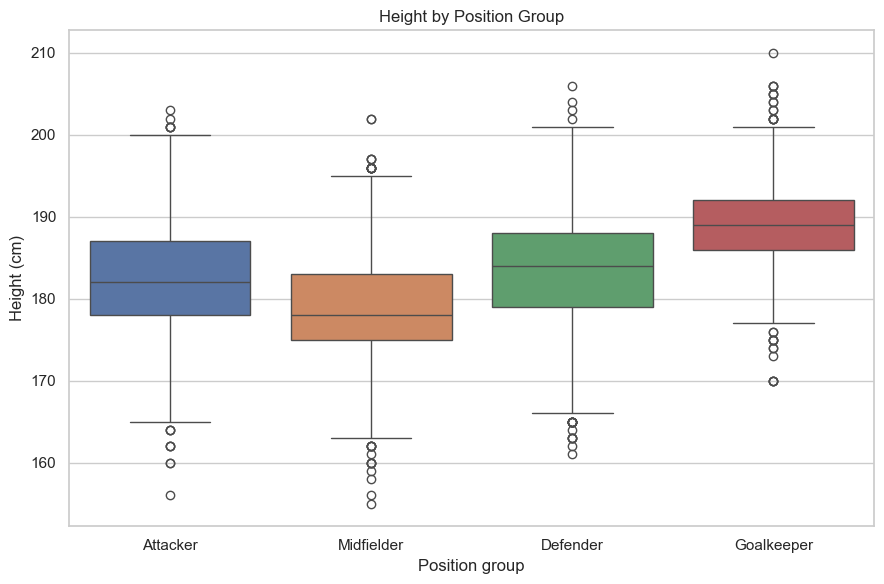

position_group
Attacker      182.1
Midfielder    178.6
Defender      183.3
Goalkeeper    189.2
Name: height_cm, dtype: float64

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = df.dropna(subset=["position_group"])
sns.boxplot(data=plot_df, x="position_group", y="height_cm", order=group_order, ax=ax, palette="deep")
ax.set_title("Height by Position Group")
ax.set_xlabel("Position group")
ax.set_ylabel("Height (cm)")
plt.tight_layout()
plt.show()

plot_df.groupby("position_group")["height_cm"].mean().loc[group_order].round(1)

**Takeaway:** goalkeepers are the tallest position group on average, as expected -
height directly aids shot-stopping reach and aerial commanding of the box. Attackers and
midfielders are shorter on average than defenders and keepers, reflecting a premium on
agility/low center of gravity for dribbling and quick direction changes versus aerial duels
and physical presence for defenders.

## 4. Preferred foot & skill attributes

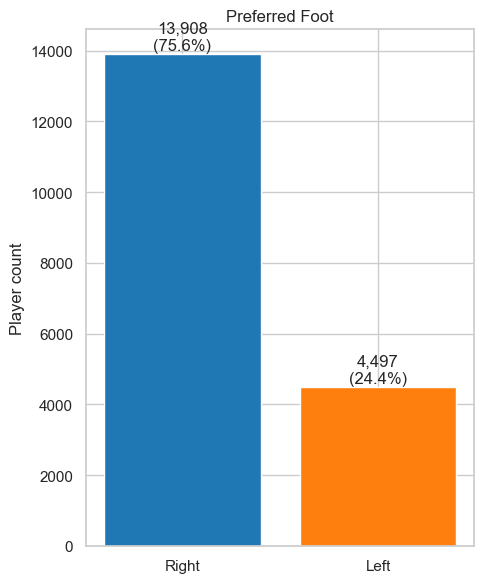

preferred_foot
Right    13908
Left      4497
Name: count, dtype: int64

In [11]:
foot_counts = df["preferred_foot"].value_counts()
foot_pct = foot_counts / foot_counts.sum() * 100
fig, ax = plt.subplots(figsize=(5, 6))
ax.bar(foot_counts.index, foot_counts.values, color=["#1f77b4", "#ff7f0e"])
ax.set_title("Preferred Foot")
ax.set_ylabel("Player count")
for i, v in enumerate(foot_counts.values):
    ax.text(i, v + 100, f"{v:,}\n({foot_pct.values[i]:.1f}%)", ha="center")
plt.tight_layout()
plt.show()

foot_counts

**Takeaway:** right-footed players outnumber left-footed players roughly 3 to 1
(75.6% vs 24.4%), consistent with the well-known real-world split in
footedness (left-footed players are a minority in the general population and are often
prized/scouted specifically for that rarity, e.g. inverted wingers).

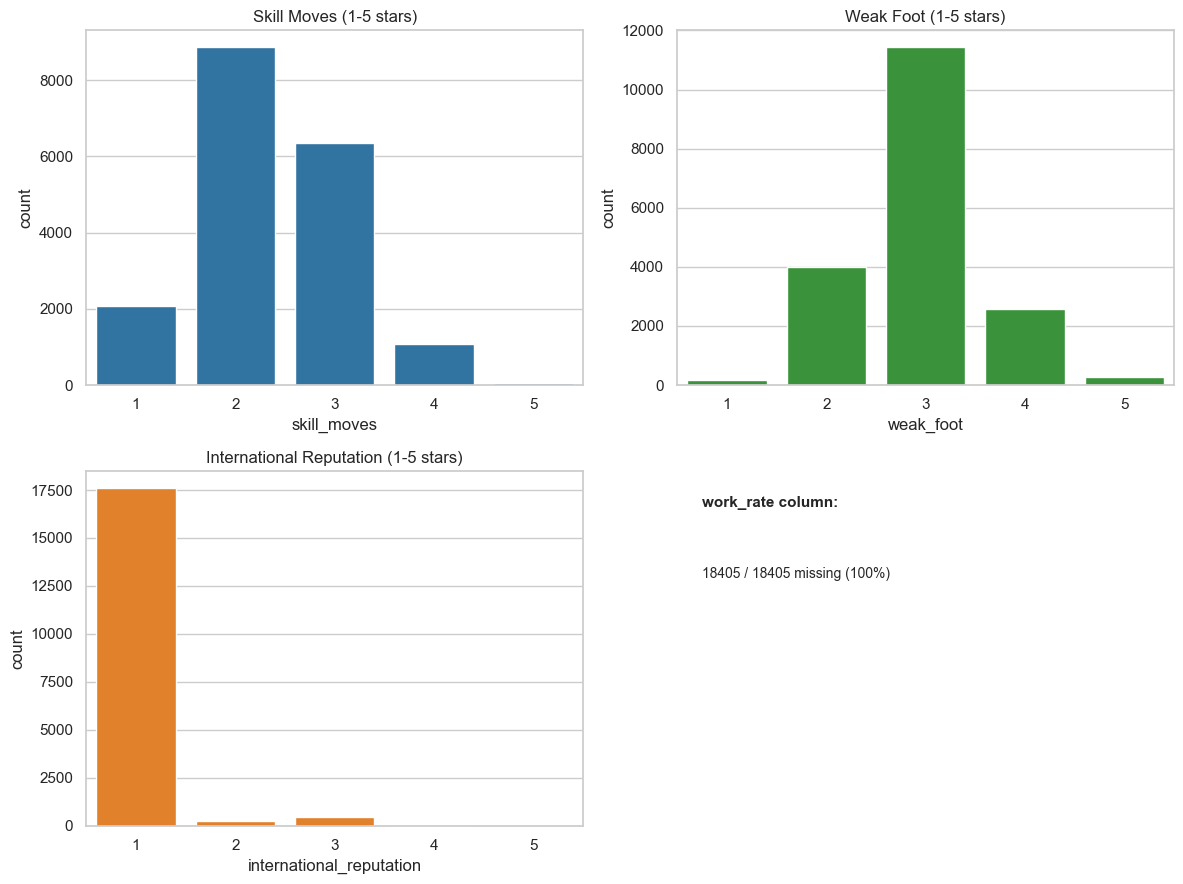

International reputation value counts:
international_reputation
1    17591
2      275
3      472
4       52
5       15
Name: count, dtype: int64


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.countplot(data=df, x="skill_moves", ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Skill Moves (1-5 stars)")

sns.countplot(data=df, x="weak_foot", ax=axes[0, 1], color="#2ca02c")
axes[0, 1].set_title("Weak Foot (1-5 stars)")

sns.countplot(data=df, x="international_reputation", ax=axes[1, 0], color="#ff7f0e")
axes[1, 0].set_title("International Reputation (1-5 stars)")

work_rate_counts = df["work_rate"].value_counts(dropna=False)
axes[1, 1].axis("off")
axes[1, 1].text(0.05, 0.9, "work_rate column:", fontsize=11, fontweight="bold", transform=axes[1, 1].transAxes)
axes[1, 1].text(0.05, 0.7, f"{df['work_rate'].isna().sum()} / {len(df)} missing ({df['work_rate'].isna().mean()*100:.0f}%)",
                fontsize=10, transform=axes[1, 1].transAxes)

plt.tight_layout()
plt.show()

print("International reputation value counts:")
print(df["international_reputation"].value_counts().sort_index())

**Takeaway:** skill moves and weak foot are both heavily concentrated at 2-3 stars,
with very few 5-star (elite) players in either category - as expected, since these are
reserved for standout dribblers/finishers. International reputation is even more skewed:
the overwhelming majority of the 18,405 players sit at 1 star, with only a handful of
globally recognized superstars reaching 4-5 stars. The `work_rate` column is entirely empty
in this cleaned export (100% missing), so it isn't usable for analysis here.

## 5. Position distribution

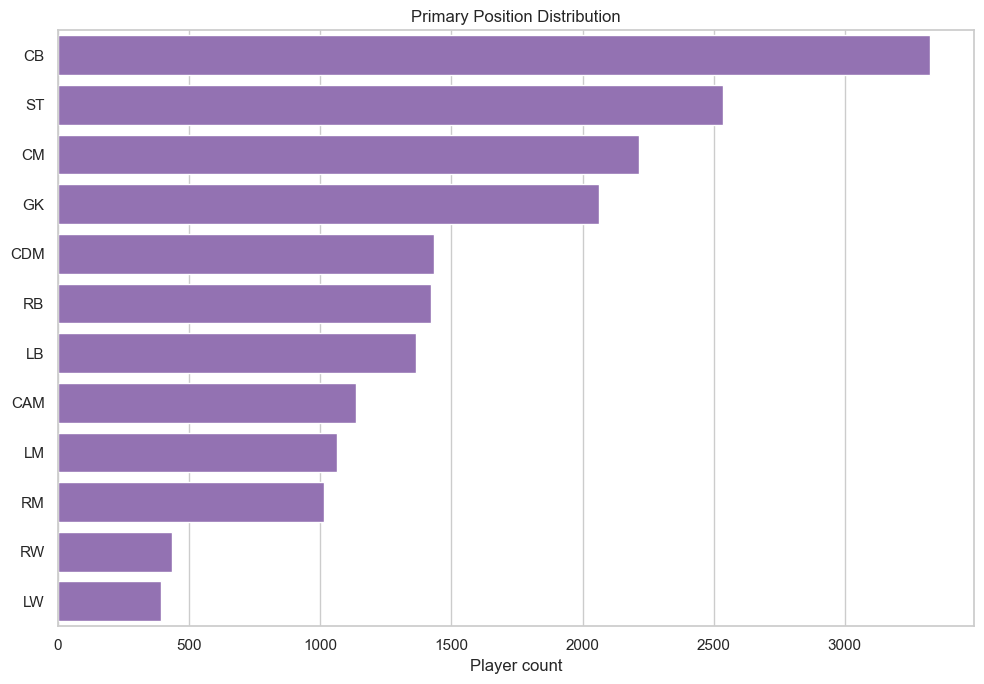

primary_position
CB     3326
ST     2534
CM     2214
GK     2062
CDM    1433
RB     1423
LB     1367
CAM    1137
LM     1064
RM     1016
RW      435
LW      394
Name: count, dtype: int64

In [13]:
pos_counts = df["primary_position"].value_counts()
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=pos_counts.values, y=pos_counts.index, ax=ax, color="#9467bd")
ax.set_title("Primary Position Distribution")
ax.set_xlabel("Player count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

pos_counts

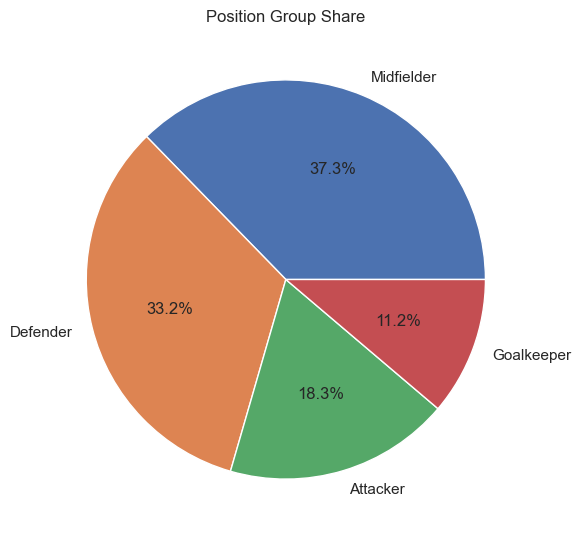

position_group
Midfielder    6864
Defender      6116
Attacker      3363
Goalkeeper    2062
Name: count, dtype: int64

In [14]:
group_counts = df["position_group"].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(group_counts.values, labels=group_counts.index, autopct="%1.1f%%",
       colors=sns.color_palette("deep", len(group_counts)))
ax.set_title("Position Group Share")
plt.tight_layout()
plt.show()

group_counts

**Takeaway:** CB is the single most common primary position (3,326
players), and midfielders are the largest position group overall (37.3% of players
with a mapped group), ahead of defenders (33.2%), attackers (18.3%), and goalkeepers
(11.2%) - unsurprising, since midfield covers the most sub-positions (CDM
through RM) and squads typically carry deep midfield rotation options. Goalkeepers are
predictably the smallest group, since squads only need 2-3 keepers versus a dozen-plus
outfield players.

## 6. League & club distribution

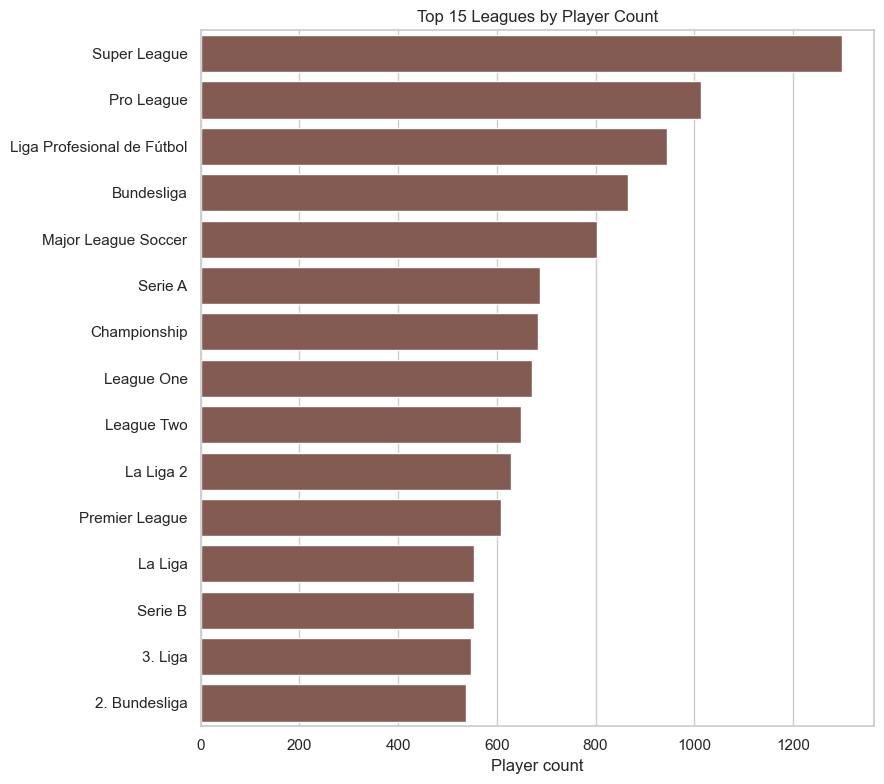

42 distinct leagues, 662 distinct clubs
89 players have no league (free agents / unattached)


league_name
Super League                  1299
Pro League                    1014
Liga Profesional de Fútbol     944
Bundesliga                     866
Major League Soccer            803
Serie A                        687
Championship                   684
League One                     672
League Two                     648
La Liga 2                      628
Premier League                 609
La Liga                        554
Serie B                        553
3. Liga                        547
2. Bundesliga                  537
Name: count, dtype: int64

In [15]:
top_leagues = df["league_name"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(x=top_leagues.values, y=top_leagues.index, ax=ax, color="#8c564b")
ax.set_title("Top 15 Leagues by Player Count")
ax.set_xlabel("Player count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"{df['league_name'].nunique()} distinct leagues, {df['club_name'].nunique()} distinct clubs")
print(f"{df['league_name'].isna().sum()} players have no league (free agents / unattached)")
top_leagues

In [16]:
league_level_counts = df.dropna(subset=["league_level"]).groupby("league_level")["overall"].agg(["count", "mean"]).round(2)
league_level_counts.index.name = "league_level (1 = top flight)"
league_level_counts

,count,mean
league_level (1 = top flight),,
1.0,13565,66.24
2.0,2884,66.00
3.0,1219,62.60
4.0,648,60.11


**Takeaway:** mean `overall` rating decreases monotonically as `league_level`
increases (i.e. dropping to lower divisions) - top-flight (`league_level` 1) players average
noticeably higher overalls than lower-division players, which is a solid sanity check that
FC26's overall ratings track a real competitive quality gradient across the football
pyramid, not just a per-player quirk. 42 leagues and 662 clubs are
represented, with 89 players unattached to any league (free agents).

## Summary

- The player pool skews young-adult (median age 25), with goalkeepers aging
  out latest and attackers trending youngest.
- Nationality is dominated by a handful of major footballing nations (England leads), with
  a long tail of 160 total nationalities - representation is broad but shallow
  outside the traditional football powers.
- Body type is really a height/build proxy, dominated by "Normal" builds in the 170-185cm
  and 185+cm bands; goalkeepers are the tallest position group, attackers/midfielders the
  shortest.
- Footedness (~76% right-footed), skill moves, weak foot, and international reputation all
  show realistic real-world skew - elite traits (5-star ratings, global reputation) are rare
  by construction.
- Midfielders are the largest position group; mean overall rating declines cleanly with
  league level, a useful sanity check for the rating validation work in notebook 02.